# Эксперимент 2: бытовое потребление электроэнергии

Этот ноутбук изучает NLCR на переменных потребления электроэнергии. Естественные ограничения здесь — энергетический баланс, неотрицательность и доли субизмерений.

In [1]:
from pathlib import Path
import os
import random
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.constraints import household_power_constraints
from src.metrics import compare_forecasts
from src.stat_tests import paired_forecast_tests, paired_loss_improvements
from src.nlcr import reconcile_many
from src.plotting import (
    plot_constraint_violations,
    plot_paired_improvement_distributions,
    plot_relative_improvements,
    plot_win_rates,
)

RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

## Заготовка данных

In [2]:
def make_demo_household_data(n=480, seed=7):
    rng = np.random.default_rng(seed)
    t = np.arange(n)

    global_wh = 550 + 160 * np.sin(2 * np.pi * t / 24) + 50 * np.sin(2 * np.pi * t / 168) + rng.normal(0, 20, n)
    global_wh = np.maximum(global_wh, 120)

    raw_shares = np.column_stack([
        0.18 + 0.04 * np.sin(2 * np.pi * t / 24),
        0.12 + 0.03 * np.cos(2 * np.pi * t / 48),
        0.10 + 0.02 * np.sin(2 * np.pi * t / 12),
    ])
    raw_shares = np.clip(raw_shares + rng.normal(0, 0.01, raw_shares.shape), 0.02, 0.35)
    share_sum = raw_shares.sum(axis=1)
    scale = np.minimum(share_sum, 0.85) / share_sum
    shares = raw_shares * scale[:, None]

    sub1, sub2, sub3 = (shares * global_wh[:, None]).T
    unmetered = global_wh - sub1 - sub2 - sub3

    return pd.DataFrame({
        "global_wh": global_wh,
        "sub1": sub1,
        "sub2": sub2,
        "sub3": sub3,
        "unmetered": unmetered,
        "s1": sub1 / global_wh,
        "s2": sub2 / global_wh,
        "s3": sub3 / global_wh,
    })


constraints = household_power_constraints()
columns = constraints.names
processed_path = PROJECT_ROOT / "data" / "processed" / "household_power" / "household_power.parquet"

if processed_path.exists():
    data = pd.read_parquet(processed_path)
    data_source = f"processed: {processed_path.relative_to(PROJECT_ROOT)}"
    data = data[columns].copy()
else:
    data = make_demo_household_data(seed=SEED)
    data_source = "demo generator; run scripts/download_data.py household_power and scripts/prepare_data.py household_power for real data"

print(data_source)
data.head()

processed: data/processed/household_power/household_power.parquet


,global_wh,sub1,sub2,sub3,unmetered,s1,s2,s3
0,2533.733333,0.0,19.0,607.0,1907.733333,0.0,0.007499,0.239567
1,3632.200000,0.0,403.0,1012.0,2217.200000,0.0,0.110952,0.278619
2,3400.233333,0.0,86.0,1001.0,2313.233333,0.0,0.025292,0.294392
3,3268.566667,0.0,0.0,1007.0,2261.566667,0.0,0.000000,0.308086
4,3056.466667,0.0,25.0,1033.0,1998.466667,0.0,0.008179,0.337972


## Базовые прогнозы

В качестве первой базовой модели каждая координата прогнозируется независимо с помощью скользящего среднего.

In [3]:
def rolling_mean_baseline(frame, test_start, windows):
    rows = []
    for t in range(test_start, len(frame)):
        rows.append([frame[col].iloc[t - window:t].mean() for col, window in zip(frame.columns, windows)])
    return pd.DataFrame(rows, columns=frame.columns, index=frame.index[test_start:])


test_size = 96
test_start = len(data) - test_size
windows = [24, 36, 30, 42, 48, 20, 28, 34]
calibration_start = max(windows)

calibration_base = rolling_mean_baseline(data[columns], calibration_start, windows)
y_calibration_true = data.iloc[calibration_start:test_start].reset_index(drop=True)
y_calibration_base = calibration_base.iloc[:test_start - calibration_start].reset_index(drop=True)
calibration_errors = y_calibration_true - y_calibration_base

y_true = data.iloc[test_start:].reset_index(drop=True)
baseline_started = perf_counter()
y_base = rolling_mean_baseline(data[columns], test_start, windows).reset_index(drop=True)
baseline_prediction_seconds = perf_counter() - baseline_started
y_base.head()

,global_wh,sub1,sub2,sub3,unmetered,s1,s2,s3
0,1430.605556,134.861111,75.566667,327.476190,577.200694,0.100744,0.050903,0.193526
1,1416.915278,134.861111,73.300000,340.523810,562.613194,0.100744,0.050903,0.207358
2,1417.733333,134.861111,73.433333,340.523810,555.328472,0.100744,0.049895,0.207358
3,1417.636111,134.861111,75.866667,340.523810,551.688194,0.100744,0.052900,0.207358
4,1418.159722,134.861111,75.466667,327.309524,551.868056,0.100744,0.052900,0.207358


## Проекция NLCR и оценивание

In [4]:
METHODS = ("ols", "wls", "shr")
y_reconciled_by_method = {}
failed_by_method = {}
reconciliation_seconds_by_method = {}

for method in METHODS:
    kwargs = {} if method == "ols" else {"errors": calibration_errors}
    reconciliation_started = perf_counter()
    y_reconciled_by_method[method], failed_by_method[method] = reconcile_many(
        y_base,
        constraints,
        method=method,
        **kwargs,
    )
    reconciliation_seconds_by_method[method] = perf_counter() - reconciliation_started

timing_rows = [{
    "experiment": "Household Power",
    "model": "rolling_mean",
    "method": "base",
    "n_forecasts": len(y_base),
    "baseline_prediction_seconds": baseline_prediction_seconds,
    "reconciliation_seconds": 0.0,
    "total_prediction_seconds": baseline_prediction_seconds,
    "overhead_seconds": 0.0,
    "slowdown_vs_base": 1.0,
    "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "reconciliation_ms_per_forecast": 0.0,
    "total_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "failed": 0,
}]
for method in METHODS:
    reconciliation_seconds = reconciliation_seconds_by_method[method]
    total_seconds = baseline_prediction_seconds + reconciliation_seconds
    timing_rows.append({
        "experiment": "Household Power",
        "model": "rolling_mean",
        "method": method,
        "n_forecasts": len(y_base),
        "baseline_prediction_seconds": baseline_prediction_seconds,
        "reconciliation_seconds": reconciliation_seconds,
        "total_prediction_seconds": total_seconds,
        "overhead_seconds": reconciliation_seconds,
        "slowdown_vs_base": total_seconds / baseline_prediction_seconds,
        "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
        "reconciliation_ms_per_forecast": 1000.0 * reconciliation_seconds / len(y_base),
        "total_ms_per_forecast": 1000.0 * total_seconds / len(y_base),
        "failed": len(failed_by_method[method]),
    })

timing_results = pd.DataFrame(timing_rows)
timing_results.to_csv(RESULTS_DIR / "tables" / "household_power_timing.csv", index=False)
failed_by_method

# Keep the OLS projection under the historical variable name for compatibility
# with existing narrative cells and quick inspection.
y_reconciled = y_reconciled_by_method["ols"]
y_reconciled.head()

,global_wh,sub1,sub2,sub3,unmetered,s1,s2,s3
0,1367.505374,197.961274,138.666878,390.576310,640.300911,0.144761,0.101401,0.285612
1,1355.791840,195.984523,134.423469,401.647194,623.736654,0.144554,0.099148,0.296245
2,1355.015954,197.578451,136.150644,403.241011,618.045848,0.145813,0.100479,0.297591
3,1354.696801,197.800386,138.805924,403.463037,614.627453,0.146011,0.102463,0.297825
4,1352.428924,200.592005,141.197532,393.040474,617.598913,0.148320,0.104403,0.290618


## Время выполнения

Ниже показано чистое время базового прогноза, накладные расходы NLCR и полное время `baseline + reconciliation`. Для честного сравнения все значения нормированы на один прогноз.

,method,n_forecasts,"baseline, ms/forecast","NLCR overhead, ms/forecast","total, ms/forecast",slowdown vs baseline,failed
0,base,96,0.663,0.000,0.663,1.0x,0
1,ols,96,0.663,11.083,11.746,17.7x,0
2,wls,96,0.663,79.259,79.922,120.5x,0
3,shr,96,0.663,104.970,105.633,159.3x,0


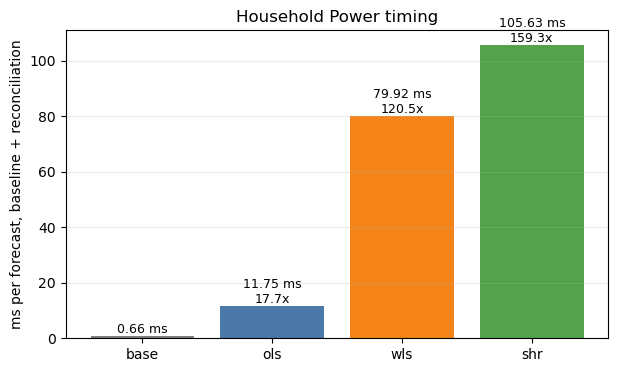

In [5]:
timing_view = timing_results.copy()
timing_view = timing_view[[
    "method", "n_forecasts", "baseline_ms_per_forecast",
    "reconciliation_ms_per_forecast", "total_ms_per_forecast",
    "slowdown_vs_base", "failed",
]].rename(columns={
    "baseline_ms_per_forecast": "baseline, ms/forecast",
    "reconciliation_ms_per_forecast": "NLCR overhead, ms/forecast",
    "total_ms_per_forecast": "total, ms/forecast",
    "slowdown_vs_base": "slowdown vs baseline",
})

display(
    timing_view.style.format({
        "baseline, ms/forecast": "{:.3f}",
        "NLCR overhead, ms/forecast": "{:.3f}",
        "total, ms/forecast": "{:.3f}",
        "slowdown vs baseline": "{:.1f}x",
    })
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_data = timing_results.set_index("method")["total_ms_per_forecast"].reindex(["base", "ols", "wls", "shr"])
bars = ax.bar(plot_data.index, plot_data.values, color=["#7E7E7E", "#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("ms per forecast, baseline + reconciliation")
ax.set_title("Household Power timing")
ax.grid(axis="y", alpha=0.25)
for bar, method in zip(bars, plot_data.index):
    row = timing_results[timing_results["method"] == method].iloc[0]
    label = f"{row['total_ms_per_forecast']:.2f} ms"
    if method != "base":
        label += f"\n{row['slowdown_vs_base']:.1f}x"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)
fig.savefig(RESULTS_DIR / "figures" / "household_power_timing.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)


## Метрики и графики

In [6]:
metric_tables = []
stat_test_tables = []
loss_improvement_tables = []

for method, y_method in y_reconciled_by_method.items():
    method_metrics = compare_forecasts(y_true, y_base, y_method, constraints)
    method_metrics["p_reconciled_better"] = method_metrics.attrs["p_reconciled_better"]
    method_metrics["method"] = method_metrics["forecast"].where(method_metrics["forecast"] == "base", method)
    method_metrics = method_metrics[method_metrics["forecast"] != "base"]
    metric_tables.append(method_metrics)

    method_stat_tests = paired_forecast_tests(y_true, y_base, y_method)
    method_stat_tests.insert(0, "method", method)
    stat_test_tables.append(method_stat_tests)

    method_loss_improvements = paired_loss_improvements(y_true, y_base, y_method)
    method_loss_improvements.insert(0, "method", method)
    loss_improvement_tables.append(method_loss_improvements)

base_metrics = compare_forecasts(y_true, y_base, y_reconciled_by_method["ols"], constraints)
base_metrics = base_metrics[base_metrics["forecast"] == "base"].copy()
base_metrics["p_reconciled_better"] = pd.NA
base_metrics["method"] = "base"

metrics = pd.concat([base_metrics, *metric_tables], ignore_index=True)
metrics.to_csv(RESULTS_DIR / "tables" / "household_power_metrics.csv", index=False)

stat_tests = pd.concat(stat_test_tables, ignore_index=True)
stat_tests.to_csv(RESULTS_DIR / "tables" / "household_power_stat_tests.csv", index=False)

loss_improvements = pd.concat(loss_improvement_tables, ignore_index=True)
loss_improvements.to_csv(RESULTS_DIR / "tables" / "household_power_loss_improvements.csv", index=False)

display(stat_tests)
metrics

,method,metric,base_loss,nlcr_loss,mean_improvement,relative_improvement_pct,win_rate,wilcoxon_stat,wilcoxon_p,sign_p,bootstrap_ci_low,bootstrap_ci_high,n_observations,n_non_ties
0,ols,mae,204.170519,205.666126,-1.495607,-0.732529,0.489583,2105.0,7.924385e-01,6.201754e-01,-5.494427,3.386662,96,96
1,ols,rmse,337.044309,335.979228,1.065080,0.316006,0.989583,4655.0,9.191488e-18,1.224312e-27,0.341845,1.674933,96,96
2,ols,smape,1.329483,1.334122,-0.004639,-0.348954,0.604167,2759.0,5.762730e-02,2.595526e-02,-0.038331,0.018714,96,96
3,wls,mae,204.170519,202.063702,2.106816,1.031890,0.625000,2827.0,3.411377e-02,9.216676e-03,-3.967428,6.205508,96,96
4,wls,rmse,337.044309,333.130915,3.913394,1.161092,0.562500,2602.0,1.583454e-01,1.307347e-01,-7.118851,10.179489,96,96
5,wls,smape,1.329483,1.326802,0.002681,0.201632,0.468750,2325.0,5.043735e-01,7.624240e-01,-0.002653,0.008957,96,96
6,shr,mae,204.170519,210.541937,-6.371419,-3.120636,0.468750,2049.0,8.460297e-01,7.624240e-01,-25.174388,19.549760,96,96
7,shr,rmse,337.044309,355.452228,-18.407919,-5.461572,0.427083,1860.0,9.563872e-01,9.373272e-01,-47.924950,19.661510,96,96
8,shr,smape,1.329483,1.375751,-0.046269,-3.480189,0.385417,1555.0,9.976344e-01,9.907833e-01,-0.082967,-0.017344,96,96


,forecast,mae,rmse,smape,constraint_violation,p_reconciled_better,method
0,base,204.170519,366.151319,1.329913,1.143185e+02,<NA>,base
1,nlcr,205.666126,365.300468,1.334122,4.294670e-12,0.989583,ols
2,nlcr,202.063702,362.812684,1.326802,9.056497e-12,0.5625,wls
3,nlcr,210.541937,408.637931,1.375826,6.952869e-12,0.427083,shr


## Статистические тесты

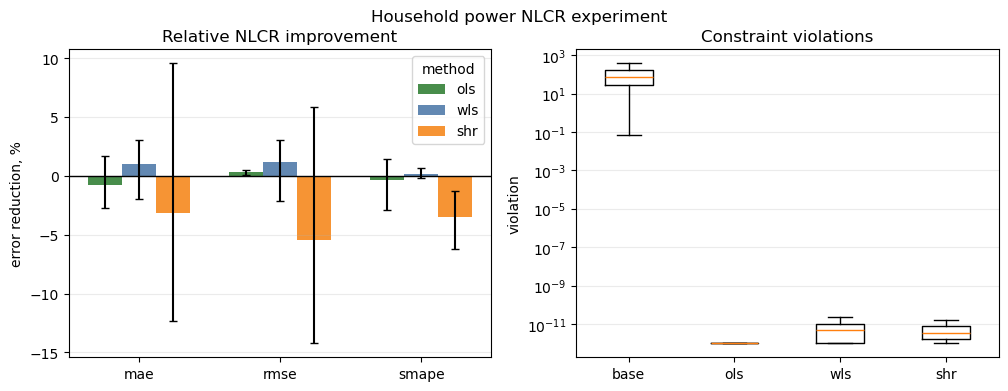

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_relative_improvements(stat_tests, ax=axes[0])
plot_constraint_violations(y_base, y_reconciled_by_method, constraints, ax=axes[1])
fig.suptitle("Household power NLCR experiment")
fig.savefig(RESULTS_DIR / "figures" / "household_power_experiment.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

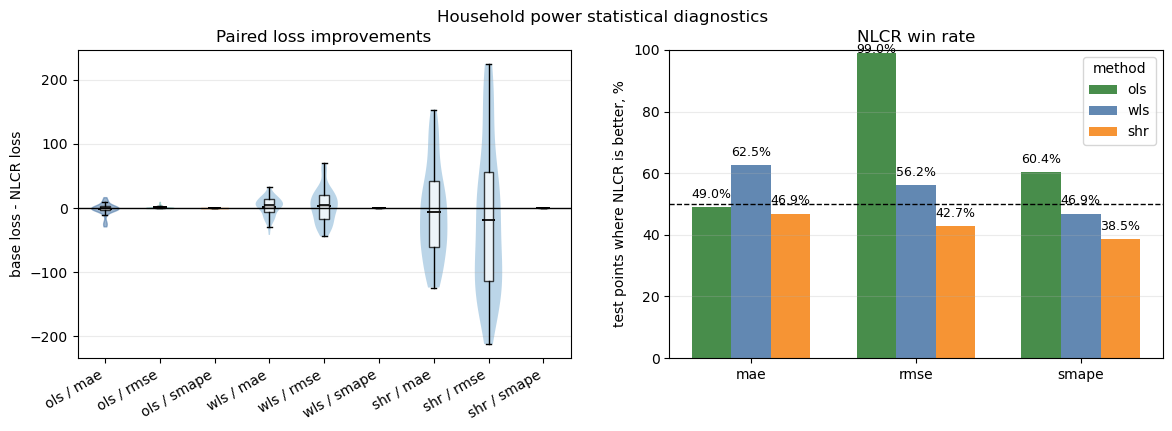

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_paired_improvement_distributions(loss_improvements, ax=axes[0])
plot_win_rates(stat_tests, ax=axes[1])
fig.suptitle("Household power statistical diagnostics")
fig.savefig(RESULTS_DIR / "figures" / "household_power_stat_tests.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Выводы по результатам эксперимента

- NLCR восстанавливает физическую согласованность энергобаланса: mean violation снижается с `114.3` до порядка `1e-11`.
- Лучший вариант по совокупности метрик — `wls`: MAE `204.17 -> 202.06`, RMSE `366.15 -> 362.81`, SMAPE `1.330 -> 1.327`; улучшение умеренное, около `0.2-1.2%`.
- `ols` улучшает RMSE, но немного ухудшает MAE/SMAPE; `shr` ухудшает все метрики. Это указывает, что полная covariance-оценка здесь менее устойчива, чем диагональный WLS.
- Эффект ограничен, вероятно, из-за шумности реальных измерений и несовпадения направления физической коррекции с направлением минимальной forecast error.

- Baseline требует `0.66` мс на прогноз. Полное время `baseline + NLCR` составляет `11.75` мс для `ols`, `79.92` мс для `wls` и `105.63` мс для `shr` (`17.7x`, `120.5x` и `159.3x` относительно baseline). Поэтому умеренный выигрыш `wls` в точности здесь имеет заметную цену по latency, а `shr` одновременно медленнее и хуже по метрикам.